<a href="https://colab.research.google.com/github/ChamiruGajasinghe/NEXORA_CNN/blob/kushen-modelA/Kushen_ModelA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3150 Assignment 03- NEXORA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.21.0


In [2]:
# image sizes
image_height = 64
image_width = 64

#this will use later during training
batch_size = 32
epochs = 20

print("Image size:", image_height, "x", image_width)

Image size: 64 x 64


In [3]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("Seed set to", seed)

Seed set to 42


## Data Preparation


In [4]:
import os
from sklearn.model_selection import train_test_split

### Loading the RealWaste dataset

In [5]:
# downloading the RealWaste dataset from UCI
!wget -q --show-progress https://archive.ics.uci.edu/static/public/908/realwaste.zip -O realwaste.zip

realwaste.zip           [ <=>                ] 656.65M  50.9MB/s    in 14s     


In [6]:
# extracting the dataset
!unzip -oq realwaste.zip -d realwaste_data

In [7]:
# extracted files
print(os.listdir("realwaste_data"))

['realwaste-main']


In [8]:
dataset_path = "realwaste_data/realwaste-main/RealWaste"

print(os.listdir(dataset_path))

['Food Organics', 'Metal', 'Textile Trash', 'Glass', 'Plastic', 'Cardboard', 'Paper', 'Miscellaneous Trash', 'Vegetation']


In [9]:
# get class names
class_names = os.listdir(dataset_path)
class_names.sort()

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Number of classes: 9


In [10]:
# count images in each class
total_images = 0

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    image_count = len(os.listdir(class_path))

    print(class_name, ":", image_count)
    total_images = total_images + image_count

print("Total images:", total_images)

Cardboard : 461
Food Organics : 411
Glass : 420
Metal : 790
Miscellaneous Trash : 495
Paper : 500
Plastic : 921
Textile Trash : 318
Vegetation : 436
Total images: 4752


### Sample images

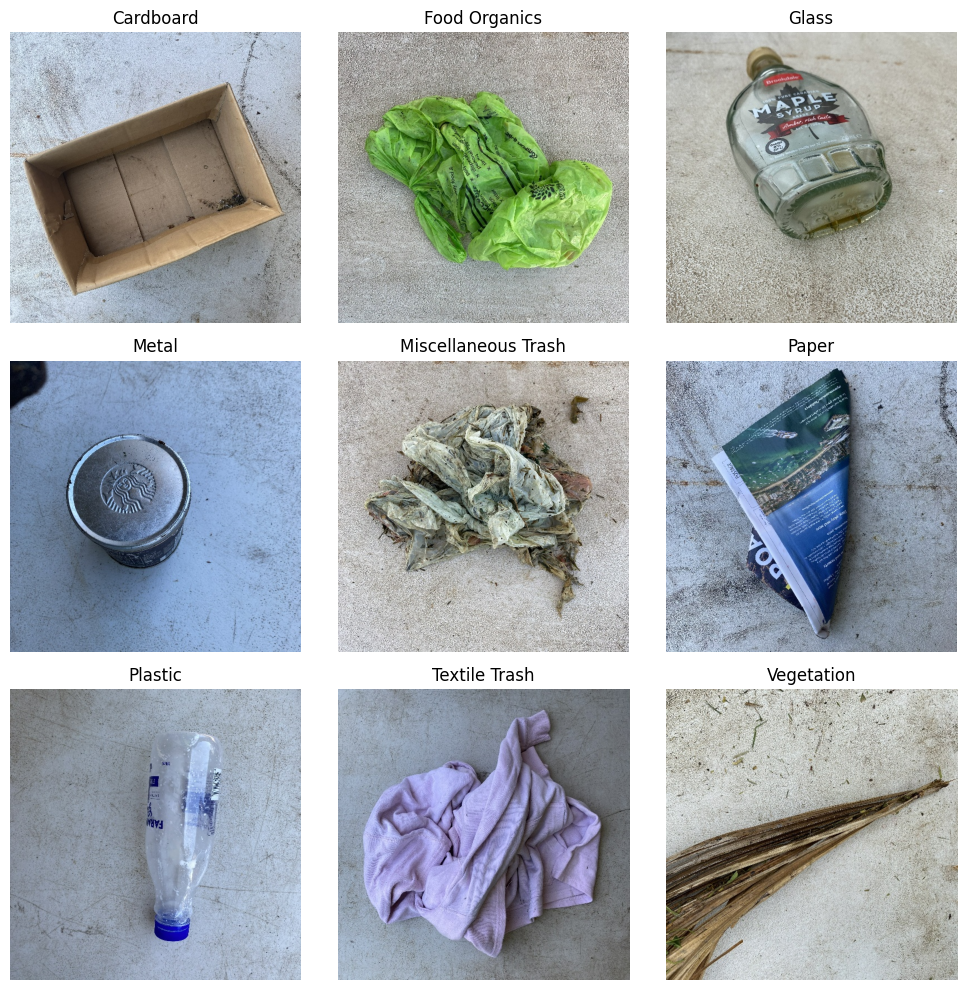

In [11]:
# show one image from each class
plt.figure(figsize=(10, 10))

for i in range(len(class_names)):
    class_name = class_names[i]
    class_path = os.path.join(dataset_path, class_name)

    image_files = os.listdir(class_path)
    image_name = image_files[0]

    image_path = os.path.join(class_path, image_name)
    image = plt.imread(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image paths and labels

In [12]:
image_paths = []
labels = []

for class_number, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = os.listdir(class_path)
    image_files.sort()

    for image_name in image_files:
        image_path = os.path.join(class_path, image_name)

        image_paths.append(image_path)
        labels.append(class_number)

print("Images:", len(image_paths))
print("Labels:", len(labels))

Images: 4752
Labels: 4752


### Train, validation and test split

In [13]:
# keep 70% for training
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=seed,
    stratify=labels
)

In [14]:
# divide the remaining 30% equally
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=seed,
    stratify=temp_labels
)

In [15]:
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 3326
Validation images: 713
Testing images: 713


In [16]:
print("Training:", round(len(train_paths) / total_images * 100, 2), "%")
print("Validation:", round(len(val_paths) / total_images * 100, 2), "%")
print("Testing:", round(len(test_paths) / total_images * 100, 2), "%")

Training: 69.99 %
Validation: 15.0 %
Testing: 15.0 %


### Image preprocessing

In [17]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(
        image,
        [image_height, image_width]
    )

    image = tf.cast(image, tf.float32)
    image = image / 255.0

    return image, label

In [18]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.map(load_image)

train_ds = train_ds.shuffle(
    len(train_paths),
    seed=seed
)

train_ds = train_ds.batch(batch_size)

In [19]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(load_image)
val_ds = val_ds.batch(batch_size)

In [20]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_ds = test_ds.map(load_image)
test_ds = test_ds.batch(batch_size)

In [21]:
for images, batch_labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", batch_labels.shape)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32,)


In [22]:
for images, batch_labels in train_ds.take(1):
    print("Minimum value:", tf.reduce_min(images).numpy())
    print("Maximum value:", tf.reduce_max(images).numpy())

Minimum value: 0.0
Maximum value: 1.0


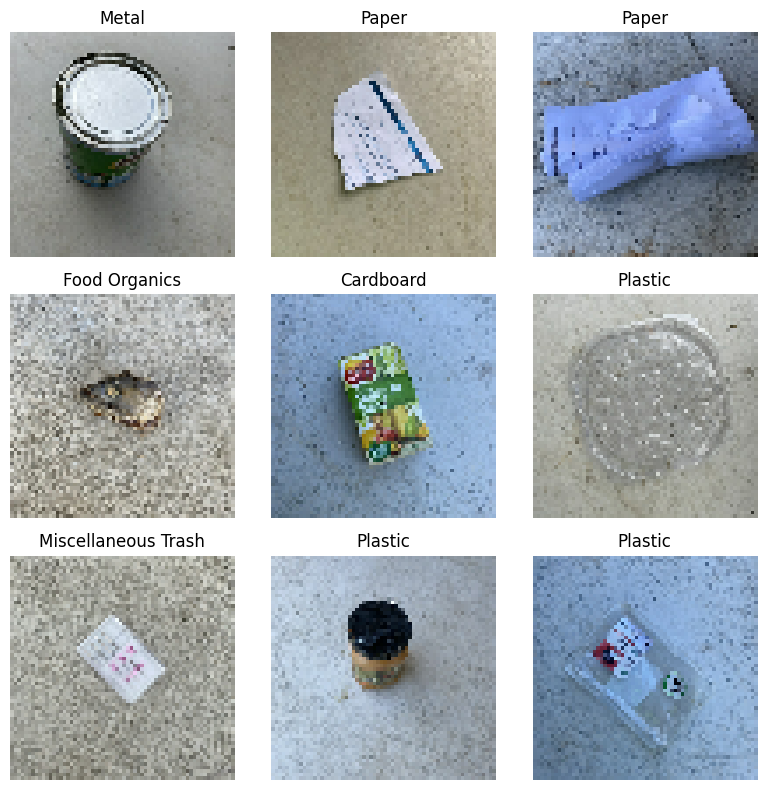

In [23]:
for images, batch_labels in train_ds.take(1):

    plt.figure(figsize=(8, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[batch_labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Model A - Standard CNN

In [24]:
# number of classes in the dataset
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 9


In [25]:
# standard CNN model

model_a = keras.Sequential([

    layers.Input(shape=(image_height, image_width, 3)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

In [26]:
model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,377 (1.09 MB)

 Trainable params: 286,377 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
total_params = model_a.count_params()

print("Total parameters:", total_params)

Total parameters: 286377


### Model A details

In [28]:
# check total number of parameters
print("Total parameters:", model_a.count_params())

Total parameters: 286377


In [29]:
# first convolution layer
conv1 = (3 * 3 * 3 * 16) + 16

# second convolution layer
conv2 = (3 * 3 * 16 * 32) + 32

# third convolution layer
conv3 = (3 * 3 * 32 * 64) + 64

print("Conv1 parameters:", conv1)
print("Conv2 parameters:", conv2)
print("Conv3 parameters:", conv3)

Conv1 parameters: 448
Conv2 parameters: 4640
Conv3 parameters: 18496


In [30]:
# after pooling, feature map size is 8 x 8 x 64
flatten_size = 8 * 8 * 64

dense1 = (flatten_size * 64) + 64
output = (64 * num_classes) + num_classes

print("Dense layer parameters:", dense1)
print("Output layer parameters:", output)

Dense layer parameters: 262208
Output layer parameters: 585


In [31]:
manual_total = conv1 + conv2 + conv3 + dense1 + output

print("Manual total:", manual_total)
print("Keras total:", model_a.count_params())

Manual total: 286377
Keras total: 286377
